# Raw File Handling Demo

Some demonstrations of functions for interacting with the datasets in sequential "time-series"-ish manner. 

In [1]:
from provenance_explorer.registry.darpa_e3_registry import E3_ALL
from provenance_explorer.registry.darpa_e5_registry import E5_ALL, REGISTRY_E5_MARPLE
from provenance_explorer.registry.darpa_optc_registry import OPTC_ALL
from provenance_explorer.raw_file_handling.dataset_iterator import make_dataset_iterator, FileEntry, _select_files
from provenance_explorer.raw_file_handling.parsing_helpers import get_ts_extractor, get_parser

from datetime import datetime, timezone
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ALL = {"e3": E3_ALL, "e5": E5_ALL, "optc": OPTC_ALL}
dumb_parse = lambda line : None

## Fast Test Run 
Demo of `test_run_seconds` covering up to 10 seconds in each file.

In [2]:
for eng, subs in ALL.items():
    for name, registry in subs.items():
        key = name.lower().replace("-", "_")
        ts_fn = get_ts_extractor(eng, key)
        parse_fn = dumb_parse # get_parser(eng, key) # expensive json parser
        it = make_dataset_iterator(registry, dumb_parse, ts_fn, test_run_seconds=10)
        count = sum(1 for _ in it)
        print(f"{eng}/{name}: {count} records")

e3/cadets: 8326 records
e3/clearscope: 389002 records
e3/fivedirections: 822626 records
e3/theia: 230757 records
e3/trace: 19965832 records
e5/cadets: 1220803 records
e5/clearscope: 1869748 records
e5/fivedirections: 7234864 records
e5/marple: 398311 records
e5/theia: 5430704 records
e5/trace: 18019022 records
optc/AIA-51-75: 67370 records
optc/AIA-201-225: 212829 records
optc/AIA-501-525: 116509 records
optc/AIA-951-975: 122158 records


## Confirm timespan iterator
Demo that iterator for time period covers only that period.

In [3]:
def dt_to_ns(s):
    dt = datetime.strptime(s, "%Y-%m-%d %H:%M:%S").replace(tzinfo=timezone.utc)
    d = dt - datetime(1970, 1, 1, tzinfo=timezone.utc)
    return (d.days * 86400 + d.seconds) * 1_000_000_000

def ns_to_dt(ns):
    return datetime.fromtimestamp(ns / 1e9, tz=timezone.utc)

windows = {
    "e3": ("2018-04-05 12:00:00", "2018-04-05 13:00:00", E3_ALL), 
    "e5": ("2019-05-09 12:00:00", "2019-05-09 13:00:00", E5_ALL), # cadets has no entries in this period which is correct
    "optc": ("2019-09-19 12:00:00", "2019-09-19 13:00:00", OPTC_ALL),
}

all_series = []

for eng, (t0_str, t1_str, subs) in windows.items():
    t0, t1 = dt_to_ns(t0_str), dt_to_ns(t1_str)
    for name, registry in subs.items():
        label = f"{eng}/{name}"
        print(f" processing {label} ...", end=" ", flush=True)
        key = name.lower().replace("-", "_")

        # this is how loops over multiple datasets are supposed to look prototypically
        it = make_dataset_iterator(
            registry, 
            dumb_parse, # get_parser(eng, key), # expensive json parser
            get_ts_extractor(eng, key),
            t_start=t0, t_end=t1,
        )
        
        timestamps = [ns_to_dt(ts) for ts, _ in it]
        print(f"{len(timestamps)} records")
        if timestamps:
            all_series.append((label, timestamps))

 processing e3/cadets ... 116371 records
 processing e3/clearscope ... 335733 records
 processing e3/fivedirections ... 679849 records
 processing e3/theia ... 72882 records
 processing e3/trace ... 2277674 records
 processing e5/cadets ... 0 records
 processing e5/clearscope ... 1591386 records
 processing e5/fivedirections ... 12929065 records
 processing e5/marple ... 3977269 records
 processing e5/theia ... 3290840 records
 processing e5/trace ... 21134764 records
 processing optc/AIA-51-75 ... 5939924 records
 processing optc/AIA-201-225 ... 6054300 records
 processing optc/AIA-501-525 ... 6038897 records
 processing optc/AIA-951-975 ... 6258863 records


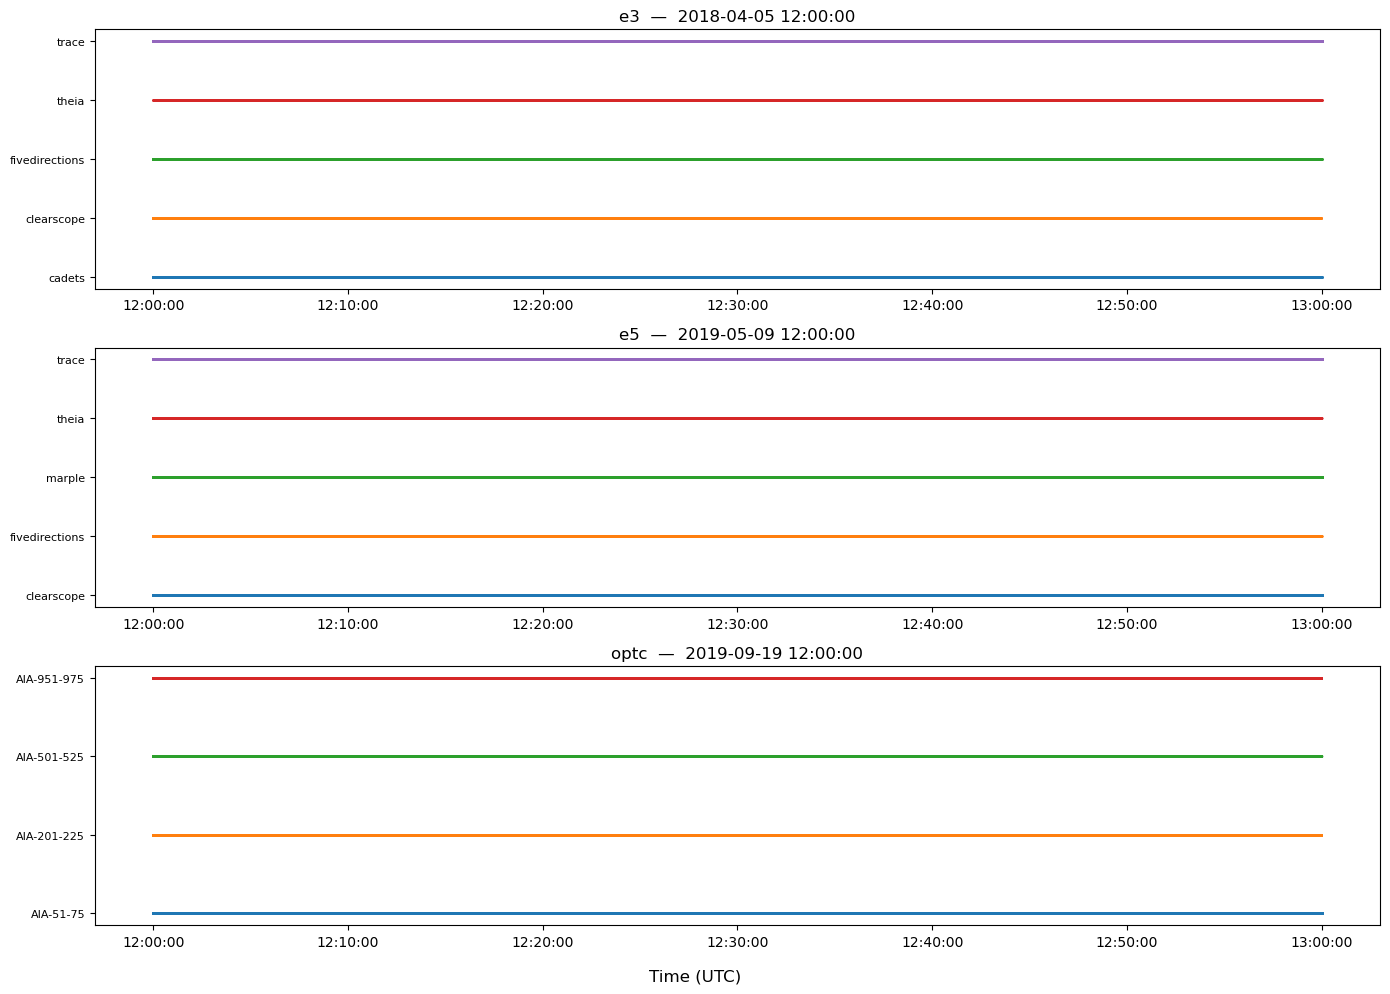

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
eng_prefixes = ["e3", "e5", "optc"]

for ax, eng in zip(axes, eng_prefixes):
    series = [(l, ts) for l, ts in all_series if l.startswith(eng + "/")]
    for i, (label, ts_list) in enumerate(series):
        ax.scatter(ts_list, [i] * len(ts_list), s=0.3, alpha=0.4, label=label)
    ax.set_yticks(range(len(series)))
    ax.set_yticklabels([s[0].split("/")[1] for s in series], fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
    ax.set_title(f"{eng}  —  {windows[eng][0]}")

fig.supxlabel("Time (UTC)")
fig.tight_layout()
plt.show()

## Confirm file overlap is handled 
There is concerning overlap, especially in a lot of E5 datasets.

E.g. take E5 Marple in the afternoon/ evening of 2019-05-12.

<img src="../../img/figures/dataset_timespans_plot/e5/marple.png" width=500 />

Demo that all overlapping files are properly handled:

In [5]:
t0 = dt_to_ns("2019-05-12 20:00:00")
t1 = dt_to_ns("2019-05-12 21:00:00")

entries = [
    FileEntry(
        filepath=f["path"],
        first_timestamp_ns=f["first_timestamp_ns"],
        last_timestamp_ns=f["last_timestamp_ns"],
        first_realistic_ts_ns=f["first_realistic_ts_ns"],
        likely_ordered=f["likely_ordered"],
        encoding=f.get("encoding", "utf-8"),
    )
    for f in REGISTRY_E5_MARPLE
]

selected = _select_files(entries, t0, t1)

print(f"Files selected: {len(selected)}\n")
for f in selected:
    s = ns_to_dt(f.first_realistic_ts_ns).strftime("%Y-%m-%d %H:%M")
    e = ns_to_dt(f.last_timestamp_ns).strftime("%Y-%m-%d %H:%M")
    print(f"{f.filepath} spanning {s} to {e}")

Files selected: 3

Engagement5/marple/ta1-marple-3-e5-official-1.jsonl.12 spanning 2019-05-12 06:46 to 2019-05-13 15:45
Engagement5/marple/ta1-marple-1-e5-official-1.jsonl.10 spanning 2019-05-12 13:55 to 2019-05-13 01:39
Engagement5/marple/ta1-marple-2-e5-official-1.jsonl.9 spanning 2019-05-12 15:40 to 2019-05-13 19:36
